# WEEK-03:DATA PREPROCESSING AND REGRESSION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt

1. Consider the hepatitis/ pima-indians-diabetes csv file, perform the following date pre-processing.
    1. Load data in Pandas.
    2. Drop columns that aren’t useful.
    3. Drop rows with missing values.
    4. Create dummy variables.
    5. Take care of missing data.
    6. Convert the data frame to NumPy.
    7. Divide the data set into training data and test data.

In [2]:
#A
df = pd.read_csv("Week 3 diabetes_csv.csv")  
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
#B - deleting unwanted column
if 'DiabetesPedigreeFunction' in df.columns:
    df.drop('DiabetesPedigreeFunction', axis=1, inplace=True)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Age,Outcome
0,6,148,72,35,0,33.6,50,1
1,1,85,66,29,0,26.6,31,0
2,8,183,64,0,0,23.3,32,1
3,1,89,66,23,94,28.1,21,0
4,0,137,40,35,168,43.1,33,1
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,63,0
764,2,122,70,27,0,36.8,27,0
765,5,121,72,23,112,26.2,30,0
766,1,126,60,0,0,30.1,47,1


In [4]:
# C
print(df.isnull().sum())
df = df.dropna()
print("\n",df.isnull().sum())
df

Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Age              0
Outcome          0
dtype: int64

 Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Age              0
Outcome          0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Age,Outcome
0,6,148,72,35,0,33.6,50,1
1,1,85,66,29,0,26.6,31,0
2,8,183,64,0,0,23.3,32,1
3,1,89,66,23,94,28.1,21,0
4,0,137,40,35,168,43.1,33,1
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,63,0
764,2,122,70,27,0,36.8,27,0
765,5,121,72,23,112,26.2,30,0
766,1,126,60,0,0,30.1,47,1


In [5]:
#D
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Age,Outcome
0,6,148,72,35,0,33.6,50,1
1,1,85,66,29,0,26.6,31,0
2,8,183,64,0,0,23.3,32,1
3,1,89,66,23,94,28.1,21,0
4,0,137,40,35,168,43.1,33,1
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,63,0
764,2,122,70,27,0,36.8,27,0
765,5,121,72,23,112,26.2,30,0
766,1,126,60,0,0,30.1,47,1


In [6]:
#E
imputer = SimpleImputer(strategy='mean')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Age,Outcome
0,6.0,148.0,72.0,35.0,0.0,33.6,50.0,1.0
1,1.0,85.0,66.0,29.0,0.0,26.6,31.0,0.0
2,8.0,183.0,64.0,0.0,0.0,23.3,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,33.0,1.0
...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,63.0,0.0
764,2.0,122.0,70.0,27.0,0.0,36.8,27.0,0.0
765,5.0,121.0,72.0,23.0,112.0,26.2,30.0,0.0
766,1.0,126.0,60.0,0.0,0.0,30.1,47.0,1.0


In [7]:
#F
data = df.to_numpy()
print("NumPy Array:")
print(data)
X = data[:, :-1]
y = data[:, -1]
df

NumPy Array:
[[  6.  148.   72.  ...  33.6  50.    1. ]
 [  1.   85.   66.  ...  26.6  31.    0. ]
 [  8.  183.   64.  ...  23.3  32.    1. ]
 ...
 [  5.  121.   72.  ...  26.2  30.    0. ]
 [  1.  126.   60.  ...  30.1  47.    1. ]
 [  1.   93.   70.  ...  30.4  23.    0. ]]


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Age,Outcome
0,6.0,148.0,72.0,35.0,0.0,33.6,50.0,1.0
1,1.0,85.0,66.0,29.0,0.0,26.6,31.0,0.0
2,8.0,183.0,64.0,0.0,0.0,23.3,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,33.0,1.0
...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,63.0,0.0
764,2.0,122.0,70.0,27.0,0.0,36.8,27.0,0.0
765,5.0,121.0,72.0,23.0,112.0,26.2,30.0,0.0
766,1.0,126.0,60.0,0.0,0.0,30.1,47.0,1.0


In [8]:
#G
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=67
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (537, 7)
Testing Features Shape: (231, 7)
Training Labels Shape: (537,)
Testing Labels Shape: (231,)


2. <br>
    1. Construct a CSV file with the following attributes:
        Study time in hours of ML lab course (x)
        Score out of 10 (y)
        The dataset should contain 10 rows.<br>
    2. Create a regression model and display the following:
       Coefficients: B0 (intercept) and B1 (slope)
        RMSE (Root Mean Square Error)
        Predicted responses<br>
    3. Create a scatter plot of the data points in red color and plot the graph of x vs. predicted y in blue color.<br>
    4. Implement the model using two methods: Pedhazur formula (intuitive)
       Calculus method (partial derivatives, refer to class notes)<br>
    5. Compare the coefficients obtained using both methods and compare them with the analytical solution.<br>
    6. Test your model to predict the score obtained when the study time of a student is 10 hours.

In [9]:
#A
data = pd.read_csv("ml_lab_data.csv")
data

,StudyTime,Score
0,1,2
1,2,3
2,3,4
3,4,5
4,5,6
5,6,7
6,7,7
7,8,8
8,9,9
9,10,10


In [26]:
#B
x = data.iloc[:,0].values
y = data.iloc[:,1].values

n = len(x)
x_mean = np.mean(x)
y_mean = np.mean(y)
B1 = np.sum((x-x_mean)*(y-y_mean)) / np.sum((x-x_mean)**2)
B0 = y_mean - B1*x_mean
print("Intercept-B0:", B0)
print("Slope-B1:", B1)

y_pred = B0 + B1*x
# RMSE
rmse = sqrt(mean_squared_error(y, y_pred))
print("RMSE =", rmse)

#MATRIX
print("\nMATRIX METHOD")
X = np.column_stack((np.ones(len(x)), x))

# β = (X'X)^(-1) X'Y
beta = np.linalg.inv(X.T @ X) @ X.T @ y

B0m = beta[0]   # Intercept
B1m = beta[1]   # Slope

print("Intercept-B0:", B0m)
print("Slope-B1:", B1m)

# Predicted values
y_pred = X @ beta

# RMSE
rmse = sqrt(mean_squared_error(y, y_pred))
print("RMSE =", rmse)

Intercept-B0: 1.4000000000000004
Slope-B1: 0.8545454545454545
RMSE = 0.2558408596267325

MATRIX METHOD
Intercept-B0: 1.4000000000000008
Slope-B1: 0.8545454545454546
RMSE = 0.2558408596267324


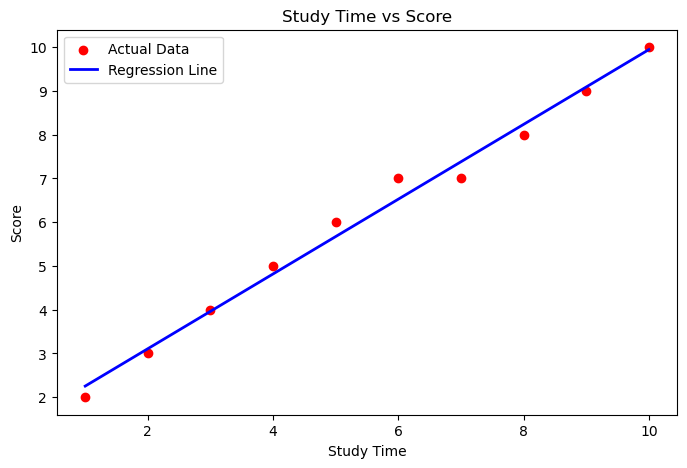

In [11]:
#C
plt.figure(figsize=(8,5))
plt.scatter(x, y, color='red', label='Actual Data')

# Regression line
plt.plot(x, y_pred, color='blue', linewidth=2, label='Regression Line')

plt.xlabel("Study Time")
plt.ylabel("Score")
plt.title("Study Time vs Score")
plt.legend()

plt.show()

In [27]:
# Pedhazur Formula
num = np.sum((x - x_mean) * (y - y_mean))
den = np.sum((x - x_mean) ** 2)

B1_pedhazur = num / den
B0_pedhazur = y_mean - B1_pedhazur * x_mean

print("Pedhazur Method")
print("Intercept (B0):", B0_pedhazur)
print("Slope (B1):", B1_pedhazur)

#Calculus Method
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x*y)
sum_x2 = np.sum(x**2)

B1_calc = (n*sum_xy - sum_x*sum_y) / (n*sum_x2 - sum_x**2)
B0_calc = (sum_y - B1_calc*sum_x) / n

print("\nCalculus Method")
print("Intercept (B0):", B0_calc)
print("Slope (B1):", B1_calc)
print("\nAll 3 methods give the same coefficient values:")
print(B1_calc==B1_pedhazur and B1==B1_calc)
print("\nComparison of Coefficients")

print("----------------------------------------")
print(f"Analytical\t{B0:.4f}\t{B1:.4f}")
print(f"Matrix\t{B0m:.4f}\t{B1m:.4f}")
print(f"Calculus\t{B0_calc:.4f}\t{B1_calc:.4f}")
print("----------------------------------------")

Pedhazur Method
Intercept (B0): 1.4000000000000004
Slope (B1): 0.8545454545454545

Calculus Method
Intercept (B0): 1.4
Slope (B1): 0.8545454545454545

All 3 methods give the same coefficient values:
True

Comparison of Coefficients
----------------------------------------
Analytical	1.4000	0.8545
Matrix	1.4000	0.8545
Calculus	1.4000	0.8545
----------------------------------------


In [13]:
study_time = int(input("Enter study time (in hours): "))

predicted_score = B0 + B1 * study_time

print("\nPredicted score =", predicted_score)

Enter study time (in hours): 5

Predicted score = 5.672727272727273


# Additional

1. <br>
        a. Consider the hepatitis/diabetes CSV file. Create a regression model and display the following:
    Coefficients: B0 (intercept) and B1 (slope)
    RMSE (Root Mean Square Error)
    Predicted responses<BR>
    b. Create a scatter plot of the data points in red color and plot the graph of x vs. predicted y in blue color.<BR>
    c. Implement the model using two methods:
    1. Pedhazur formula (intuitive)
    2. Calculus method (partial derivatives, refer to class notes)<BR>
    d. Compare the coefficients obtained using both methods. For a given data point, check the predicted y
    value.

In [14]:
dfh = pd.read_csv("Week 3 hepatitis_csv.csv")  
dfh

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,class
0,30,male,False,False,False,False,False,False,False,False,False,False,False,1.0,85.0,18.0,4.0,NaN,False,live
1,50,female,False,False,True,False,False,False,False,False,False,False,False,0.9,135.0,42.0,3.5,NaN,False,live
2,78,female,True,False,True,False,False,True,False,False,False,False,False,0.7,96.0,32.0,4.0,NaN,False,live
3,31,female,NaN,True,False,False,False,True,False,False,False,False,False,0.7,46.0,52.0,4.0,80.0,False,live
4,34,female,True,False,False,False,False,True,False,False,False,False,False,1.0,NaN,200.0,4.0,NaN,False,live
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,46,female,True,False,True,True,True,True,False,False,True,True,True,7.6,NaN,242.0,3.3,50.0,True,die
151,44,female,True,False,True,False,False,True,True,False,False,False,False,0.9,126.0,142.0,4.3,NaN,True,live
152,61,female,False,False,True,True,False,False,True,False,True,False,False,0.8,75.0,20.0,4.1,NaN,True,live
153,53,male,False,False,True,False,False,True,False,True,True,False,True,1.5,81.0,19.0,4.1,48.0,True,live


In [15]:
#a
df_clean = dfh.dropna(subset=["age", "albumin"])

x = df_clean["age"].values
y = df_clean["albumin"].values
n = len(x)
x_bar = np.mean(x)
y_bar = np.mean(y)
B1 = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2)
B0 = y_bar - B1 * x_bar

print("Intercept-B0:", B0)
print("Slope-B1:", B1)

y_pred = B0 + B1 * x
rmse = sqrt(mean_squared_error(y, y_pred))
print("\nRMSE =", rmse)

Intercept-B0: 4.380329675524193
Slope-B1: -0.013788905020765107

RMSE = 0.6263250194913464


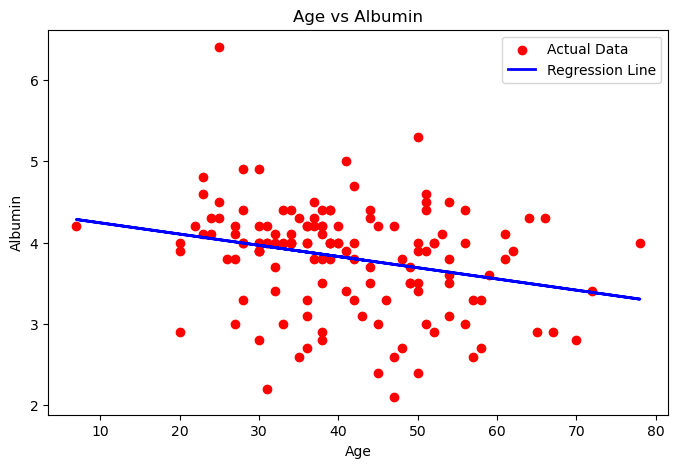

In [16]:
#b
plt.figure(figsize=(8,5))
plt.scatter(x, y, color='red', label='Actual Data')

# Regression line
plt.plot(x, y_pred, color='blue', linewidth=2, label='Regression Line')

plt.xlabel("Age")
plt.ylabel("Albumin")
plt.title("Age vs Albumin")
plt.legend()

plt.show()

In [17]:
#C
# Pedhazur Formula
num = np.sum((x - x_bar) * (y - y_bar))
den = np.sum((x - x_bar) ** 2)

B1h_pedhazur = num / den
B0h_pedhazur = y_bar - B1h_pedhazur * x_bar

print("Pedhazur Method")
print("Intercept (B0):", B0h_pedhazur)
print("Slope (B1):", B1h_pedhazur)

#Calculus Method
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x*y)
sum_x2 = np.sum(x**2)

B1h_calc = (n*sum_xy - sum_x*sum_y) / (n*sum_x2 - sum_x**2)
B0h_calc = (sum_y - B1h_calc*sum_x) / n

print("\nCalculus Method")
print("Intercept (B0):", B0h_calc)
print("Slope (B1):", B1h_calc)
print("\nAll 3 methods give the same coefficient values:")
print(B1h_calc==B1h_pedhazur and B1==B1_calc)

Pedhazur Method
Intercept (B0): 4.380329675524193
Slope (B1): -0.013788905020765107

Calculus Method
Intercept (B0): 4.380329675524194
Slope (B1): -0.013788905020765133

All 3 methods give the same coefficient values:
False


In [18]:
#d
print("Comparison of Coefficients")

print("----------------------------------------")
print(f"Analytical\t{B0:.4f}\t{B1:.4f}")
print(f"Pedhazur\t{B0h_pedhazur:.4f}\t{B1h_pedhazur:.4f}")
print(f"Calculus\t{B0h_calc:.4f}\t{B1h_calc:.4f}")
age = int(input("Enter age: "))

predicted_albumin = B0 + B1 * age

print("\nPredicted score =", predicted_albumin)

Comparison of Coefficients
----------------------------------------
Analytical	4.3803	-0.0138
Pedhazur	4.3803	-0.0138
Calculus	4.3803	-0.0138
Enter age: 12

Predicted score = 4.214862815275011
